## Primitive version of Creating Decision Tree

In [4]:
# Ensure required Python packages are installed in the notebook environment
try:
    import graphviz, dtreeviz
    print("Required Python packages are already installed: graphviz, dtreeviz")
except ModuleNotFoundError:
    print("Installing required packages: graphviz, dtreeviz")
    # Use notebook pip magic which installs into the active kernel environment
    %pip install graphviz dtreeviz
    print("Installation finished. You may need to restart the kernel if imports still fail.")

Installing required packages: graphviz, dtreeviz
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached dtreeviz-2.2.2-py3-none-any.whl.metadata (2.4 kB)
  Using cached colour-0.1.5-py2.py3-none-any.whl.metadata (18 kB)
  Using cached pytest-9.0.2-py3-none-any.whl.metadata (7.6 kB)
  Using cached iniconfig-2.3.0-py3-none-any.whl.metadata (2.5 kB)
  Using cached pluggy-1.6.0-py3-none-any.whl.metadata (4.8 kB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)
Using cached dtreeviz-2.2.2-py3-none-any.whl (91 kB)
Using cached colour-0.1.5-py2.py3-none-any.whl (23 kB)
Using cached pytest-9.0.2-py3-none-any.whl (374 kB)
Using cached pluggy-1.6.0-py3-none-any.whl (20 kB)
Using cached iniconfig-2.3.0-py3-none-any.whl (7.5 kB)

   -------------------- ------------------- 3/6 [graphviz]
   -------------------------- ------------- 4/6 [pytest]
   -------------------------- ------------- 4/6 [pytest]
   --------------------------------- ------ 5/6 [dtreeviz]
   -----------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


**Note:** dtreeviz uses the Graphviz system executable to render figures. On Windows, download and install Graphviz (https://graphviz.org/download/), add the Graphviz `bin` directory to your PATH, and restart the kernel if visualization fails.

In [ ]:
# informational note cell (was accidentally a python cell)

In [5]:
# Use graphviz backend if available
try:
    import graphviz.backend as be
except ModuleNotFoundError as e:
    raise ModuleNotFoundError("Missing python package 'graphviz'. Run the install cell above or '%pip install graphviz'.") from e

In [17]:
# Imports for decision tree visualization
from sklearn.datasets import load_iris, load_wine, load_breast_cancer
try:
    # the convenience function is provided at the package root
    from dtreeviz import dtreeviz
except (ModuleNotFoundError, ImportError) as e:
    raise ModuleNotFoundError(
        "Missing 'dtreeviz' package or its 'dtreeviz' entry point. Run the install cell above or '%pip install dtreeviz'. "
        "Also ensure Graphviz (system) is installed and in PATH for rendering."
    ) from e

from IPython.display import Image, display_svg, SVG

In [14]:
# Diagnostic: inspect dtreeviz package
import dtreeviz
import dtreeviz.trees as dtrees
print("dtreeviz version:", getattr(dtreeviz, '__version__', 'unknown'))
print("dtreeviz.trees members:", [m for m in dir(dtrees) if not m.startswith('_')])

dtreeviz version: 2.2.2
dtreeviz.trees members: ['Callable', 'Color', 'DTreeVizAPI', 'DTreeVizRender', 'List', 'Mapping', 'NUM_BINS', 'ShadowDecTree', 'ShadowDecTreeNode', 'add_classifier_legend', 'adjust_colors', 'explain_prediction_plain_english', 'explain_prediction_sklearn_default', 'is_numeric', 'matplotlib', 'model', 'myround', 'np', 'os', 'patches', 'pd', 'plt', 'rgb2hex', 'tempfile', 'tessellate', 'tree']


In [12]:
from dtreeviz.trees import DTreeVizRender
print([m for m in dir(DTreeVizRender) if not m.startswith('_')])

['save', 'save_svg', 'show', 'svg', 'view']


In [ ]:
# Try rendering via dtreeviz.trees.tree + DTreeVizRender
from dtreeviz.trees import tree, DTreeVizRender
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from IPython.display import SVG, display

iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names = list(iris.target_names)
clf = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X, y)

dot = tree(clf, X, y, feature_names=feature_names, class_names=class_names, target_name='species')
viz = DTreeVizRender(dot)
svg = viz.svg()
display(SVG(svg))

TypeError: DTreeVizRender.__init__() got an unexpected keyword argument 'feature_names'

In [13]:
import inspect
print(inspect.signature(DTreeVizRender.__init__))
print(DTreeVizRender.__init__.__doc__)

(self, dot, scale=1.0)
None


In [ ]:
import inspect
from dtreeviz.trees import tree
print('tree signature:', inspect.signature(tree))
print('\nFirst line of doc:')
print(tree.__doc__.splitlines()[0])

In [16]:
import graphviz.backend as be

In [2]:
from sklearn.datasets import *
from dtreeviz import *
from IPython.display import Image,display_svg, SVG

In [6]:
# ensure the classifier is available in this cell
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris

clf = DecisionTreeClassifier()
iris = load_iris()

X_train = iris.data
y_train = iris.target
clf.fit(X_train, y_train)



,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.9166666666666666, 'x[3] <= 0.8\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.4230769230769231, 0.75, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.46153846153846156, 0.8333333333333333, 'True  '),
 Text(0.5769230769230769, 0.75, 'x[3] <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.5384615384615384, 0.8333333333333333, '  False'),
 Text(0.3076923076923077, 0.5833333333333334, 'x[2] <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.15384615384615385, 0.4166666666666667, 'x[3] <= 1.65\ngini = 0.041\nsamples = 48\nvalue = [0, 47, 1]'),
 Text(0.07692307692307693, 0.25, 'gini = 0.0\nsamples = 47\nvalue = [0, 47, 0]'),
 Text(0.23076923076923078, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.46153846153846156, 0.4166666666666667, 'x[3] <= 1.55\ngini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.38461538461538464, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.5384615384615384, 0.25, '

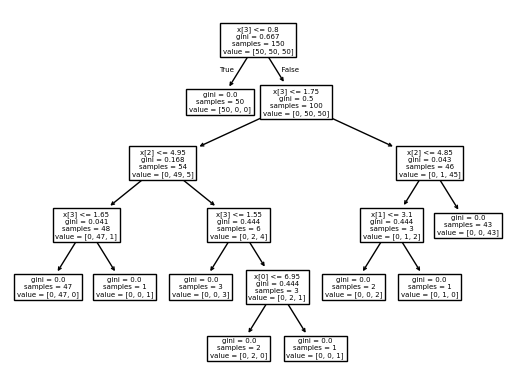

In [11]:
from sklearn.tree import plot_tree
plot_tree(clf)

## 1. Classification

In [15]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from dtreeviz import model

iris = load_iris()
X, y = iris.data, iris.target

clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X, y)

viz_model = model(
    clf,
    X_train=X,
    y_train=y,
    feature_names=iris.feature_names,
    class_names=iris.target_names
)

viz_model.view()


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


ExecutableNotFound: failed to execute 'dot', make sure the Graphviz executables are on your systems' PATH